In [16]:
import os
import pandas as pd
import numpy as np
import random
import optuna
import json
import math
import time

# Sembunyikan log Optuna agar terminal bersih
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET_FOLDER = os.path.join('osmnx_inputs')

try:
    # Memuat berkas data dasar dari folder target
    matriks_jarak = pd.read_csv(os.path.join(TARGET_FOLDER, 'distance_matrix_osmnx.csv'), index_col=0)
    matriks_jalan = pd.read_csv(os.path.join(TARGET_FOLDER, 'road_condition_matrix_osmnx.csv'), index_col=0)
    matriks_elevasi = pd.read_csv(os.path.join(TARGET_FOLDER, 'elevation_matrix_surabaya.csv'), index_col=0)
    df_cluster = pd.read_csv(os.path.join(TARGET_FOLDER, 'destinasi_clustered_real_distance.csv'))
    
    ROUTE_JSON_PATH = os.path.join(TARGET_FOLDER, 'route_polyline_registry.json')
    with open(ROUTE_JSON_PATH, 'r') as f:
        route_registry = json.load(f)
        
    names = matriks_jarak.index.tolist()

    # Konversi ke NumPy Array untuk komputasi cepat di dalam engine algoritma
    dist_np = matriks_jarak.to_numpy()
    road_np = matriks_jalan.to_numpy()
    elev_np = matriks_elevasi.to_numpy()
    cluster_np = df_cluster['Cluster_ID'].to_numpy()

    print("=" * 65)
    print("🚲 PRE-FLIGHT SANITY CHECK: KAPASITAS USER")
    print("=" * 65)

    BANNED_NODES = []
    MAX_KM_USER = 20.10
    
    while True:
        try:
            input_user = input("\nMasukkan batas maksimal jarak per hari (Km) [Tekan Enter untuk default 20.10]: ")
            if input_user.strip():
                MAX_KM_USER = float(input_user)
            else:
                MAX_KM_USER = 25.0
        except ValueError:
            print("❌ Masukkan angka yang valid!")
            continue

        max_m = MAX_KM_USER * 1000
        infeasible_nodes = []

        for i in range(1, len(names)):
            jarak_pp = dist_np[0, i] + dist_np[i, 0]
            if jarak_pp > max_m:
                infeasible_nodes.append((i, names[i], jarak_pp))

        if infeasible_nodes:
            print(f"\n⚠️ WARNING: Ditemukan {len(infeasible_nodes)} destinasi yang jarak PP-nya saja sudah melebihi {MAX_KM_USER} km!")
            for idx, nama, jarak in infeasible_nodes:
                print(f"   - {nama} (Jarak PP mutlak: {round(jarak/1000, 2)} km)")
            
            opsi = input("\nApakah kamu ingin MENGHAPUS destinasi di atas agar model tetap feasible? (y/n): ").strip().lower()
            if opsi == 'y':
                print("✅ Destinasi infeasible di-blacklist dari pencarian rute.")
                BANNED_NODES = [n[0] for n in infeasible_nodes]
                break
            else:
                print("❌ Pencarian dibatalkan. Silakan masukkan limit yang lebih besar untuk menjangkau destinasi tersebut.")
        else:
            BANNED_NODES = []
            print("✅ Semua destinasi lolos uji kapasitas fisik harian!")
            break

except FileNotFoundError as e:
    print(f"[ERROR] Berkas data preprocessing tidak ditemukan: {e}")

🚲 PRE-FLIGHT SANITY CHECK: KAPASITAS USER
✅ Semua destinasi lolos uji kapasitas fisik harian!


In [67]:
# ─────────────────────────────────────────────────────────────────────
# 1. FUNGSI FITNESS ACO 
# ─────────────────────────────────────────────────────────────────────
def hitung_fitness_aco_final(solusi_multi_hari, dist_np, elev_np, road_np, cluster_np, max_km_user):
    w_jarak = 10.0
    w_jalan = 5.0
    w_penalti_cluster = 50.0 
    w_hari = 30.0  
    
    fitness_total = len(solusi_multi_hari) * w_hari
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_multi_hari, start=1):
        if idx_hari % 2 != 0:
            nama_hari = f"Pekan {(idx_hari+1)//2} - Sabtu (Jalan Berat)"
            w_penalti_fatigue = 1.5; w_penalti_jarak = 5.0     
        else:
            nama_hari = f"Pekan {idx_hari//2} - Minggu (Recovery)"
            w_penalti_fatigue = 8.0; w_penalti_jarak = 25.0    
            
        jarak_m = fatigue = skor_jalan = p_cluster = 0.0
        
        for k in range(len(rute) - 1):
            a, t = rute[k], rute[k+1]
            
            dm = dist_np[a, t]
            dz = elev_np[a, t]
            js = road_np[a, t]
            
            jarak_m += dm
            skor_jalan += js
            
            if dz > 0 and dm > 0: 
                fatigue += dm * ((dz / dm) ** 2) * 400.0
            else: 
                fatigue += dm * 0.0001
                
            if a != 0 and t != 0:
                if cluster_np[a-1] != cluster_np[t-1]:
                    p_cluster += w_penalti_cluster

        jkm = jarak_m / 1000.0
        p_jarak = max(0.0, jkm - max_km_user) * w_penalti_jarak  
        p_fatigue = fatigue * w_penalti_fatigue
            
        fitness_hari = (jkm * w_jarak) + (skor_jalan * w_jalan) + p_jarak + p_fatigue + p_cluster
        fitness_total += fitness_hari
        
        log_itinerary.append({
            "Hari/Trip": nama_hari, "Jarak (Km)": round(jkm, 2),
            "Fatigue Index": round(fatigue, 2), "Skor Jalan OSMnx": round(skor_jalan, 2),
            "P_Fatigue": round(p_fatigue, 2), "P_Cluster": round(p_cluster, 2),
            "Fitness Score": round(fitness_hari, 2)
        })
        
    return fitness_total, log_itinerary

# ─────────────────────────────────────────────────────────────────────
# 2. CORE ENGINE ACO (DENGAN BLACKLIST NODE)
# ─────────────────────────────────────────────────────────────────────
# TAMBAHAN: Parameter banned_nodes dimasukkan ke engine
def run_aco_final(dist_np, elev_np, road_np, cluster_np, alpha, beta, evaporation, max_km_user, banned_nodes, num_ants=15, iterations=30):
    num_nodes = len(dist_np)
    max_m = max_km_user * 1000
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    max_dist = dist_np.max()
    max_elev = elev_np.max() 
    if max_elev <= 0: max_elev = 1.0 
    
    best_score = float('inf')
    best_route = []
    best_log = None
    
    # Trackers untuk Grafik Konvergensi
    hist_fitness = []
    hist_dist = []
    hist_days = []
    
    for _ in range(iterations):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for ant in range(num_ants):
            # FILTER BLACKLIST: Semut hanya melihat destinasi yang tidak di-banned
            destinasi_tersisa = [i for i in range(1, num_nodes) if i not in banned_nodes]
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0]
                jarak_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    curr = rute_hari_ini[-1]
                    
                    valid_candidates = []
                    for cand in destinasi_tersisa:
                        uji_dist = dist_np[curr, cand]
                        jarak_kembali_hotel = dist_np[cand, 0]
                        if jarak_hari + uji_dist + jarak_kembali_hotel <= max_m:
                            valid_candidates.append(cand)
                            
                    if not valid_candidates:
                        break 
                        
                    probs = []
                    for cand in valid_candidates:
                        tau = pheromone[curr][cand] ** alpha
                        d_ij = dist_np[curr, cand]
                        road_ij = road_np[curr, cand]
                        dz = elev_np[curr, cand]
                        
                        d_norm = d_ij / max_dist
                        r_norm = road_ij / 5.0
                        
                        cluster_norm = 0.0
                        if curr != 0 and cand != 0:
                            if cluster_np[curr-1] != cluster_np[cand-1]: 
                                cluster_norm = 0.15 
                                
                        if len(rute_multi_hari) % 2 == 0:
                            eta = 1.0 / (0.8 * d_norm + 0.2 * r_norm + cluster_norm + 0.001)
                        else:
                            f_local = max(0, dz)
                            f_norm = f_local / (max_elev + 1e-6) 
                            eta = 1.0 / (0.5 * d_norm + 0.2 * r_norm + 0.3 * f_norm + cluster_norm + 0.001)
                            
                        probs.append(tau * (eta ** beta))
                        
                    sum_p = sum(probs)
                    if sum_p == 0: next_c = random.choice(valid_candidates)
                    else: next_c = random.choices(valid_candidates, weights=[p/sum_p for p in probs], k=1)[0]
                    
                    rute_hari_ini.append(next_c)
                    jarak_hari += dist_np[curr, next_c]
                    destinasi_tersisa.remove(next_c)
                    
                rute_hari_ini.append(0)
                
                if len(rute_hari_ini) == 2:
                    raise ValueError(f"Infeasible Error Lolos: Terdapat rute destinasi yang jarak PP-nya melebihi {max_km_user} km.")
                
                rute_multi_hari.append(rute_hari_ini)
                
            f_score, lg = hitung_fitness_aco_final(rute_multi_hari, dist_np, elev_np, road_np, cluster_np, max_km_user)
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(f_score)
            list_log_semut.append(lg)
            
            if f_score < best_score:
                best_score = f_score
                best_route = rute_multi_hari
                best_log = lg
                
        pheromone *= (1.0 - evaporation)
        for idx, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx]
            if fit_value > 0:
                deposit = 2000 / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit
        
        # Simpan metrik terbaik per iterasi
        hist_fitness.append(best_score)
        tot_dist = sum(l["Jarak (Km)"] for l in best_log)
        hist_dist.append(tot_dist)
        hist_days.append(len(best_route))
                        
    return best_score, best_route, best_log, hist_fitness, hist_dist, hist_days

print("\n" + "=" * 65)
print("🐜 TUNING PARAMETER ACO FINAL DENGAN DATASET OSMNX LOKAL")
print("=" * 65)

def objective_aco(trial):
    alpha = trial.suggest_float('alpha', 0.1, 1.5)
    beta = trial.suggest_float('beta', 2.0, 8.0)
    evaporation = trial.suggest_float('evaporation', 0.05, 0.5)
    score, _, _, _, _, _ = run_aco_final(dist_np, elev_np, road_np, cluster_np, alpha, beta, evaporation, max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_ants=15, iterations=15)
    return score

study_aco = optuna.create_study(direction='minimize')
study_aco.optimize(objective_aco, n_trials=20)
best_p_aco = study_aco.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final ACO dengan Parameter Terbaik...")
score_aco, rute_aco, log_aco, hist_fitness_aco, hist_dist_aco, hist_days_aco = run_aco_final(
    dist_np, elev_np, road_np, cluster_np, alpha=best_p_aco['alpha'], beta=best_p_aco['beta'], evaporation=best_p_aco['evaporation'], max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_ants=40, iterations=50
)
print(f"✔ [ACO Selesai] Fitness Score Terbaik: {round(score_aco, 2)}")
print(f"   ↳ Skor Optuna Terbaik : {round(study_aco.best_value, 4)}")
print(f"   ↳ Parameter Terbaik   : {best_p_aco}")


🐜 TUNING PARAMETER ACO FINAL DENGAN DATASET OSMNX LOKAL

▶ Mengeksekusi Eksperimen Final ACO dengan Parameter Terbaik...
✔ [ACO Selesai] Fitness Score Terbaik: 23460.28
   ↳ Skor Optuna Terbaik : 22123.513
   ↳ Parameter Terbaik   : {'alpha': 1.3049464536221231, 'beta': 5.581254539205062, 'evaporation': 0.29397910735842886}


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CELL SA REVISI: SIMULATED ANNEALING DENGAN SPATIAL CLUSTER GUIDANCE
# ─────────────────────────────────────────────────────────────────────

def buat_urutan_awal_clusteraware_sa(num_nodes, dist_np, cluster_np, banned_nodes, noise=0.2, w_cluster=0.15):
    """
    REVISI VARIANCE FIX: Inisialisasi solusi awal SA dengan Nearest-Neighbor +
    CLUSTER GUIDANCE (sama seperti pada ACO/PSO/GA), bukan permutasi acak murni.

    Permutasi acak murni membuat titik start tiap run (seed berbeda) sangat
    jauh berbeda secara spasial, sehingga SA mendarat di local optimum yang
    sangat berbeda-beda antar run -> Std Dev fitness jadi besar.

    Dengan starting point yang konsisten secara spasial (kandidat se-cluster
    diberi diskon jarak), variasi antar-run jadi lebih kecil sementara proses
    annealing tetap memberi ruang eksplorasi (lewat noise & SA itu sendiri).
    """
    destinasi_tersisa = set(i for i in range(1, num_nodes) if i not in banned_nodes)
    urutan = []
    curr = 0
    while destinasi_tersisa:
        kandidat = list(destinasi_tersisa)

        def skor(cand):
            d = dist_np[curr, cand]
            if curr != 0 and cluster_np[curr - 1] == cluster_np[cand - 1]:
                d = d * (1.0 - w_cluster)
            return d

        kandidat.sort(key=skor)
        if noise > 0 and len(kandidat) > 1 and random.random() < noise:
            pilih = kandidat[random.randint(1, min(2, len(kandidat) - 1))]
        else:
            pilih = kandidat[0]
        urutan.append(pilih)
        destinasi_tersisa.remove(pilih)
        curr = pilih
    return urutan


def buat_solusi_awal_sa(num_nodes, dist_np, cluster_np, max_km_user, banned_nodes):
    # REVISI VARIANCE FIX: ganti dasar urutan dari "random.shuffle murni"
    # menjadi "Nearest-Neighbor + Cluster Guidance" agar starting point
    # antar-run lebih konsisten secara spasial (mengurangi Std Dev SA).
    destinasi_tersisa = buat_urutan_awal_clusteraware_sa(num_nodes, dist_np, cluster_np, banned_nodes, noise=0.2, w_cluster=0.15)
    
    max_m = max_km_user * 1000
    solusi_multi_hari = []
    rute_hari_ini = [0]
    jarak_hari = 0.0
    
    for cand in destinasi_tersisa:
        curr = rute_hari_ini[-1]
        uji_dist = dist_np[curr, cand]
        jarak_kembali_hotel = dist_np[cand, 0]
        
        if jarak_hari + uji_dist + jarak_kembali_hotel <= max_m:
            rute_hari_ini.append(cand)
            jarak_hari += uji_dist
        else:
            rute_hari_ini.append(0)
            solusi_multi_hari.append(rute_hari_ini)
            rute_hari_ini = [0, cand]
            jarak_hari = dist_np[0, cand]
            
    rute_hari_ini.append(0)
    solusi_multi_hari.append(rute_hari_ini)
    return solusi_multi_hari

def hitung_jarak_rute_tunggal(rute, dist_np):
    return sum(dist_np[rute[k], rute[k+1]] for k in range(len(rute) - 1))

def ambil_cluster_mayoritas_hari(rute, cluster_np):
    """Mencari Cluster ID yang paling sering dikunjungi dalam satu hari"""
    nodes_wisata = [n for n in rute if n != 0]
    if not nodes_wisata: 
        return -1
    list_cluster = [cluster_np[n-1] for n in nodes_wisata]
    return max(set(list_cluster), key=list_cluster.count)

def modifikasi_solusi_tetangga_cepat_sa(solusi_sekarang, dist_np, cluster_np, max_km_user):
    """
    ENGINE SPATIAL GUIDANCE: Mengintegrasikan Cluster sebagai Kompas Spasial.
    Menuntun SA menaruh destinasi ke hari yang sewilayah secara cerdas.
    """
    max_m = max_km_user * 1000
    solusi_baru = [rute[:] for rute in solusi_sekarang]
    pilihan_mutasi = random.random()
    
    # Kategori 1: Intra-Cluster Local Search (Tukar internal dalam hari yang sama)
    if pilihan_mutasi < 0.4 and len(solusi_baru) > 0:
        idx_hari = random.randint(0, len(solusi_baru) - 1)
        rute_pilihan = solusi_baru[idx_hari][:]
        if len(rute_pilihan) > 3:
            i, j = random.sample(range(1, len(rute_pilihan) - 1), 2)
            rute_pilihan[i], rute_pilihan[j] = rute_pilihan[j], rute_pilihan[i]
            
            if hitung_jarak_rute_tunggal(rute_pilihan, dist_np) <= max_m:
                solusi_baru[idx_hari] = rute_pilihan
            
    # Kategori 2: Inter-Day Move dipandu oleh Spatial Cluster Guidance
    elif len(solusi_baru) > 1:
        hari_asal = random.randint(0, len(solusi_baru) - 1)
        if len(solusi_baru[hari_asal]) > 3:
            rute_asal_temp = solusi_baru[hari_asal][:]
            idx_node = random.randint(1, len(rute_asal_temp) - 2)
            node_pindahan = rute_asal_temp[idx_node]
            cluster_node = cluster_np[node_pindahan - 1]
            
            # Cari hari yang mayoritas clusternya cocok dengan cluster node pindahan
            kandidat_hari_tujuan = []
            for h_idx, rute_tgt in enumerate(solusi_baru):
                if h_idx != hari_asal:
                    cluster_mayoritas = ambil_cluster_mayoritas_hari(rute_tgt, cluster_np)
                    if cluster_mayoritas == cluster_node:
                        kandidat_hari_tujuan.append(h_idx)
            
            # 85% Dipandu kompas cluster, sisanya dieksplorasi acak
            if kandidat_hari_tujuan and random.random() < 0.85:
                hari_tujuan = random.choice(kandidat_hari_tujuan)
            else:
                list_pilihan = [h for h in range(len(solusi_baru)) if h != hari_asal]
                hari_tujuan = random.choice(list_pilihan)
                
            rute_tujuan_temp = solusi_baru[hari_tujuan][:]
            rute_asal_temp.pop(idx_node)
            
            ins_pos = random.randint(1, max(1, len(rute_tujuan_temp) - 1))
            rute_tujuan_temp.insert(ins_pos, node_pindahan)
            
            # Validasi batasan kapasitas jarak user
            if hitung_jarak_rute_tunggal(rute_tujuan_temp, dist_np) <= max_m:
                solusi_baru[hari_asal] = rute_asal_temp
                solusi_baru[hari_tujuan] = rute_tujuan_temp
            
    solusi_baru = [rute for rute in solusi_baru if len(rute) > 2]
    if not solusi_baru: 
        return solusi_sekarang
        
    return solusi_baru

def run_sa_final(dist_np, elev_np, road_np, cluster_np, temp_awal, cooling_rate, temp_min, max_km_user, banned_nodes, seed=42):
    random.seed(seed)
    num_nodes = len(dist_np)
    
    solusi_sekarang = buat_solusi_awal_sa(num_nodes, dist_np, cluster_np, max_km_user, banned_nodes)
    
    # Menyelaraskan fungsi hitung_fitness sesuai dengan notebook lokal Anda
    # (Bisa diubah ke hitung_fitness_universal jika nama fungsinya sudah di-update)
    best_score, best_log = hitung_fitness_aco_final(solusi_sekarang, dist_np, elev_np, road_np, cluster_np, max_km_user)
    
    best_route = solusi_sekarang
    score_sekarang = best_score
    t = temp_awal
    
    while t > temp_min:
        solusi_tetangga = modifikasi_solusi_tetangga_cepat_sa(solusi_sekarang, dist_np, cluster_np, max_km_user)
        score_tetangga, log_tetangga = hitung_fitness_aco_final(solusi_tetangga, dist_np, elev_np, road_np, cluster_np, max_km_user)
        
        delta_energi = score_tetangga - score_sekarang
        
        if delta_energi < 0 or random.random() < math.exp(-delta_energi / t):
            solusi_sekarang = solusi_tetangga
            score_sekarang = score_tetangga
            
            if score_sekarang < best_score:
                best_score = score_sekarang
                best_route = solusi_sekarang
                best_log = log_tetangga
                
        t *= cooling_rate
        
    # Mengembalikan 3 parameter agar kompatibel dengan pemanggilan fungsi Anda
    return best_score, best_route, best_log

# ─────────────────────────────────────────────────────────────────────
# OPTUNA TUNING & EKSEKUSI EXPERIMEN FINAL
# ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("🌡️  TUNING PARAMETER SA FINAL DENGAN SPATIAL CLUSTER GUIDANCE")
print("=" * 65)

def objective_sa(trial):
    temp_awal = trial.suggest_float('temp_awal', 1000.0, 5000.0)
    cooling_rate = trial.suggest_float('cooling_rate', 0.950, 0.999)
    temp_min = trial.suggest_float('temp_min', 0.001, 1.0, log=True)
    
    score, _, _ = run_sa_final(
        dist_np, elev_np, road_np, cluster_np, 
        temp_awal, cooling_rate, temp_min, 
        max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, seed=42
    )
    return score

study_sa = optuna.create_study(direction='minimize')
study_sa.optimize(objective_sa, n_trials=20)
best_p_sa = study_sa.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final SA dengan Parameter Terbaik...")
score_sa, rute_sa, log_sa = run_sa_final(
    dist_np, elev_np, road_np, cluster_np, 
    temp_awal=best_p_sa['temp_awal'], 
    cooling_rate=best_p_sa['cooling_rate'], 
    temp_min=best_p_sa['temp_min'], 
    max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, seed=42
)
print(f"✔ [SA Selesai] Fitness Score Terbaik: {round(score_sa, 2)}")
print(f"   ↳ Skor Optuna Terbaik : {round(study_sa.best_value, 4)}")
print(f"   ↳ Parameter Terbaik   : {best_p_sa}")


🌡️  TUNING PARAMETER SA FINAL DENGAN SPATIAL CLUSTER GUIDANCE

▶ Mengeksekusi Eksperimen Final SA dengan Parameter Terbaik...
✔ [SA Selesai] Fitness Score Terbaik: 22364.07
   ↳ Skor Optuna Terbaik : 22364.0726
   ↳ Parameter Terbaik   : {'temp_awal': 1520.4986412784715, 'cooling_rate': 0.9954426085320317, 'temp_min': 0.00317797922007103}


In [69]:
def buat_partikel_nn_pso(num_nodes, dist_np, max_km_user, banned_nodes, noise=0.0):
    """
    Bangun partikel awal dengan heuristik Nearest-Neighbor dari depot.
    noise=0   -> murni nearest-neighbor (deterministik)
    noise>0   -> ada probabilitas memilih kandidat ke-2/ke-3 terdekat
                 (untuk variasi antar partikel "smart" agar tidak identik)
    """
    destinasi_tersisa = set(i for i in range(1, num_nodes) if i not in banned_nodes)
    urutan = []
    curr = 0
    while destinasi_tersisa:
        kandidat = sorted(destinasi_tersisa, key=lambda x: dist_np[curr, x])
        if noise > 0 and len(kandidat) > 1 and random.random() < noise:
            pilih = kandidat[random.randint(1, min(2, len(kandidat) - 1))]
        else:
            pilih = kandidat[0]
        urutan.append(pilih)
        destinasi_tersisa.remove(pilih)
        curr = pilih
    return urutan

def buat_partikel_awal_pso(num_nodes, dist_np, max_km_user, banned_nodes):
    """Partikel awal full-random (permutasi acak murni)."""
    destinasi_tersisa = [i for i in range(1, num_nodes) if i not in banned_nodes]
    random.shuffle(destinasi_tersisa)
    return destinasi_tersisa

def buat_partikel_clusteraware_pso(num_nodes, dist_np, cluster_np, max_km_user, banned_nodes, noise=0.2, w_cluster=0.15):
    """
    Bangun partikel awal dengan heuristik Nearest-Neighbor + CLUSTER GUIDANCE.

    Sama seperti ACO: saat memilih destinasi berikutnya, kandidat yang berada
    pada Cluster_ID YANG SAMA dengan node saat ini diberi skor jarak lebih
    "murah" (dikalikan 1 - w_cluster), sehingga lebih disukai dibanding
    kandidat dari cluster lain meski jaraknya mirip.

    Dengan ini cluster digunakan sebagai SPATIAL GUIDANCE sejak konstruksi
    partikel awal PSO, bukan hanya sebagai penalti fitness setelah solusi jadi.
    """
    destinasi_tersisa = set(i for i in range(1, num_nodes) if i not in banned_nodes)
    urutan = []
    curr = 0
    while destinasi_tersisa:
        kandidat = list(destinasi_tersisa)

        def skor(cand):
            d = dist_np[curr, cand]
            if curr != 0 and cluster_np[curr - 1] == cluster_np[cand - 1]:
                d = d * (1.0 - w_cluster)  # diskon jarak untuk kandidat se-cluster
            return d

        kandidat.sort(key=skor)
        if noise > 0 and len(kandidat) > 1 and random.random() < noise:
            pilih = kandidat[random.randint(1, min(2, len(kandidat) - 1))]
        else:
            pilih = kandidat[0]
        urutan.append(pilih)
        destinasi_tersisa.remove(pilih)
        curr = pilih
    return urutan

def permutasi_ke_solusi_multi_hari(urutan_flat, dist_np, max_km_user):
    """Potong permutasi flat menjadi rute multi-hari berdasarkan batas Km harian."""
    max_m = max_km_user * 1000; solusi = []; rute_hari_ini = [0]; jarak_hari = 0.0
    for cand in urutan_flat:
        curr = rute_hari_ini[-1]
        if jarak_hari + dist_np[curr, cand] + dist_np[cand, 0] <= max_m:
            rute_hari_ini.append(cand); jarak_hari += dist_np[curr, cand]
        else:
            rute_hari_ini.append(0); solusi.append(rute_hari_ini)
            rute_hari_ini = [0, cand]; jarak_hari = dist_np[0, cand]
    rute_hari_ini.append(0); solusi.append(rute_hari_ini)
    return solusi

def swap_sequence_pso(urutan_a, urutan_b):
    """Hitung Swap Sequence (SO) yang mengubah urutan_a -> urutan_b."""
    a = list(urutan_a); b = list(urutan_b); swaps = []
    for i in range(len(b)):
        if a[i] != b[i]:
            j = a.index(b[i], i)
            swaps.append((i, j)); a[i], a[j] = a[j], a[i]
    return swaps

def terapkan_swaps_parsial_pso(urutan, swaps, probabilitas):
    """Terapkan tiap swap dalam Swap Sequence dengan probabilitas tertentu."""
    r = list(urutan)
    for i, j in swaps:
        if random.random() < probabilitas:
            r[i], r[j] = r[j], r[i]
    return r

def local_search_2swap_pso(urutan, dist_np, elev_np, road_np, cluster_np, max_km_user, score_sekarang, n_coba=3, prob_cluster_guided=0.5):
    """
    Local search ringan: coba beberapa 2-swap, terima kalau lebih baik.
    Dipilih kembali dari 2-opt karena 2-opt (segment reversal) terbukti
    destruktif pada representasi "permutasi-terpotong-per-hari" -- reversal
    di tengah permutasi mengubah drastis bagaimana sisa permutasi terpotong
    jadi hari-hari berikutnya (efek domino), sedangkan 2-swap hanya
    mempertukarkan dua node sehingga dampaknya lebih lokal & terkendali.

    CLUSTER GUIDANCE: dengan probabilitas `prob_cluster_guided`, swap yang
    dicoba bukan acak murni, melainkan diarahkan -- mencari sepasang node
    yang BERBEDA cluster dan saling bertukar posisi, dengan harapan
    mendekatkan node ke tetangga se-cluster (mengurangi P_Cluster sekaligus
    merapatkan rute secara spasial). Ini meniru peran cluster sebagai
    "peta petunjuk eksplorasi" pada ACO, diterapkan pada tahap perbaikan
    solusi PSO.
    """
    best_urutan = urutan
    best_score = score_sekarang
    n = len(best_urutan)
    for _ in range(n_coba):
        cand = best_urutan[:]

        if prob_cluster_guided > 0 and random.random() < prob_cluster_guided and n > 1:
            # Cari pasangan posisi yang node-nya berbeda cluster -> swap
            ia = random.randrange(n)
            node_a = cand[ia]
            cluster_a = cluster_np[node_a - 1]
            kandidat_idx = [j for j in range(n) if cluster_np[cand[j] - 1] != cluster_a]
            if kandidat_idx:
                ib = random.choice(kandidat_idx)
            else:
                ib = random.randrange(n)
            if ib == ia:
                ib = (ib + 1) % n
        else:
            ia, ib = random.sample(range(n), 2)

        cand[ia], cand[ib] = cand[ib], cand[ia]
        sol = permutasi_ke_solusi_multi_hari(cand, dist_np, max_km_user)
        s, lg = hitung_fitness_aco_final(sol, dist_np, elev_np, road_np, cluster_np, max_km_user)
        if s < best_score:
            best_score = s; best_urutan = cand
    return best_urutan, best_score


def run_pso_final(dist_np, elev_np, road_np, cluster_np, w, c1, c2, max_km_user, banned_nodes,
                  num_particles=15, iterations=30, seed=42, n_elite=2):
    random.seed(seed); np.random.seed(seed)
    num_nodes = len(dist_np)

    # ── Inisialisasi swarm HYBRID + CLUSTER-AWARE ────────────────────
    # ~25% partikel: Nearest-Neighbor + Cluster Guidance (spatial guidance,
    #                cluster jadi diskon jarak saat memilih kandidat, mirip ACO)
    # ~25% partikel: Nearest-Neighbor murni (smart start, noise antar partikel)
    # ~50% partikel: full-random (diversitas/eksplorasi)
    particles = []
    n_cluster_aware = max(1, int(0.25 * num_particles))
    n_smart = max(1, int(0.25 * num_particles))
    for _ in range(n_cluster_aware):
        particles.append(buat_partikel_clusteraware_pso(num_nodes, dist_np, cluster_np, max_km_user, banned_nodes, noise=0.2, w_cluster=0.15))
    for _ in range(n_smart):
        particles.append(buat_partikel_nn_pso(num_nodes, dist_np, max_km_user, banned_nodes, noise=0.3))
    for _ in range(num_particles - n_cluster_aware - n_smart):
        particles.append(buat_partikel_awal_pso(num_nodes, dist_np, max_km_user, banned_nodes))

    pbest_perm = [p[:] for p in particles]
    pbest_score = []
    pbest_log = []
    for p in particles:
        solusi = permutasi_ke_solusi_multi_hari(p, dist_np, max_km_user)
        s, lg = hitung_fitness_aco_final(solusi, dist_np, elev_np, road_np, cluster_np, max_km_user)
        pbest_score.append(s); pbest_log.append(lg)

    gbest_idx = int(np.argmin(pbest_score))
    gbest_perm = pbest_perm[gbest_idx][:]
    gbest_score = pbest_score[gbest_idx]
    gbest_route = permutasi_ke_solusi_multi_hari(gbest_perm, dist_np, max_km_user)
    gbest_log = pbest_log[gbest_idx]

    # Normalisasi bobot velocity: w + c1 + c2 dipetakan jadi probabilitas
    total_w = w + c1 + c2

    # ── Loop utama PSO ────────────────────────────────────────────────
    for _ in range(iterations):
        # Elitism: urutkan partikel berdasarkan pbest_score saat ini,
        # n_elite terbaik dilindungi dari inersia acak (tetap dapat
        # kognitif/sosial + local search lebih intensif)
        urutan_elite = set(np.argsort(pbest_score)[:n_elite].tolist())

        for i in range(num_particles):
            r1 = random.random(); r2 = random.random()
            perm = particles[i][:]
            is_elite = i in urutan_elite

            # Inersia: swap acak kecil sebagai eksplorasi/momentum.
            # Partikel elite TIDAK kena inersia acak (dilindungi).
            if not is_elite:
                n_inertia_swap = max(0, round((w / total_w) * 3))
                for _ in range(n_inertia_swap):
                    ia, ib = random.sample(range(len(perm)), 2)
                    perm[ia], perm[ib] = perm[ib], perm[ia]

            # Kognitif: tarik proporsional ke personal best
            prob_cog = (c1 * r1) / total_w
            perm = terapkan_swaps_parsial_pso(perm, swap_sequence_pso(perm, pbest_perm[i]), prob_cog)

            # Sosial: tarik proporsional ke global best
            prob_soc = (c2 * r2) / total_w
            perm = terapkan_swaps_parsial_pso(perm, swap_sequence_pso(perm, gbest_perm), prob_soc)

            # Validasi permutasi
            if set(perm) == set(particles[i]):
                particles[i] = perm

            solusi = permutasi_ke_solusi_multi_hari(particles[i], dist_np, max_km_user)
            s, lg = hitung_fitness_aco_final(solusi, dist_np, elev_np, road_np, cluster_np, max_km_user)

            # Local search 2-swap (perbaikan halus).
            # Partikel elite mendapat lebih banyak percobaan local search.
            n_coba = 6 if is_elite else 3
            new_perm, new_s = local_search_2swap_pso(
                particles[i], dist_np, elev_np, road_np, cluster_np, max_km_user, s, n_coba=n_coba
            )
            if new_s < s:
                particles[i] = new_perm; s = new_s
                solusi = permutasi_ke_solusi_multi_hari(particles[i], dist_np, max_km_user)
                s, lg = hitung_fitness_aco_final(solusi, dist_np, elev_np, road_np, cluster_np, max_km_user)

            if s < pbest_score[i]:
                pbest_score[i] = s; pbest_perm[i] = particles[i][:]; pbest_log[i] = lg

            if s < gbest_score:
                gbest_score = s; gbest_perm = particles[i][:]
                gbest_route = solusi; gbest_log = lg

    return gbest_score, gbest_route, gbest_log


print("\n" + "=" * 65)
print("🕊️  TUNING PARAMETER PSO FINAL DENGAN DATASET OSMNX LOKAL")
print("=" * 65)

def objective_pso(trial):
    w = trial.suggest_float('w', 0.1, 0.9)
    c1 = trial.suggest_float('c1', 0.5, 2.5)
    c2 = trial.suggest_float('c2', 0.5, 2.5)
    score, _, _ = run_pso_final(dist_np, elev_np, road_np, cluster_np, w, c1, c2, max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_particles=20, iterations=20, seed=42)
    return score

study_pso = optuna.create_study(direction='minimize')
study_pso.optimize(objective_pso, n_trials=20)
best_p_pso = study_pso.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final PSO dengan Parameter Terbaik...")
score_pso, rute_pso, log_pso = run_pso_final(
    dist_np, elev_np, road_np, cluster_np, w=best_p_pso['w'], c1=best_p_pso['c1'], c2=best_p_pso['c2'], max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_particles=60, iterations=100, seed=42
)
print(f"✔ [PSO Selesai] Fitness Score Terbaik: {round(score_pso, 2)}")
print(f"   ↳ Skor Optuna Terbaik : {round(study_pso.best_value, 4)}")
print(f"   ↳ Parameter Terbaik   : {best_p_pso}")


🕊️  TUNING PARAMETER PSO FINAL DENGAN DATASET OSMNX LOKAL

▶ Mengeksekusi Eksperimen Final PSO dengan Parameter Terbaik...
✔ [PSO Selesai] Fitness Score Terbaik: 25481.09
   ↳ Skor Optuna Terbaik : 27040.7246
   ↳ Parameter Terbaik   : {'w': 0.44167363043033325, 'c1': 0.5491577317886224, 'c2': 2.420517196214999}


In [70]:
# ─────────────────────────────────────────────────────────────────────
# 1. FUNGSI FITNESS GA (MULTI-WEEKEND & TERKALIBRASI LOKAL)
# ─────────────────────────────────────────────────────────────────────
def hitung_fitness_ga_final(solusi_multi_hari, dist_np, elev_np, road_np, cluster_np, max_km_user):
    w_jarak = 10.0
    w_jalan = 5.0
    w_penalti_cluster = 50.0 
    w_hari = 30.0  # PARAMETER SACRED KELOMPOK (TIDAK DIUBAH)
    
    fitness_total = len(solusi_multi_hari) * w_hari
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_multi_hari, start=1):
        if idx_hari % 2 != 0:
            nama_hari = f"Pekan {(idx_hari+1)//2} - Sabtu (Jalan Berat)"
            w_penalti_fatigue = 1.5; w_penalti_jarak = 5.0     
        else:
            nama_hari = f"Pekan {idx_hari//2} - Minggu (Recovery)"
            w_penalti_fatigue = 8.0; w_penalti_jarak = 25.0    
            
        jarak_m = fatigue = skor_jalan = p_cluster = 0.0
        
        for k in range(len(rute) - 1):
            a, t = rute[k], rute[k+1]
            
            dm = dist_np[a, t]
            dz = elev_np[a, t]
            js = road_np[a, t]
            
            jarak_m += dm
            skor_jalan += js
            
            if dz > 0 and dm > 0: 
                fatigue += dm * ((dz / dm) ** 2) * 400.0
            else: 
                fatigue += dm * 0.0001
                
            if a != 0 and t != 0:
                if cluster_np[a-1] != cluster_np[t-1]:
                    p_cluster += w_penalti_cluster

        jkm = jarak_m / 1000.0
        p_jarak = max(0.0, jkm - max_km_user) * w_penalti_jarak  
        p_fatigue = fatigue * w_penalti_fatigue
            
        fitness_hari = (jkm * w_jarak) + (skor_jalan * w_jalan) + p_jarak + p_fatigue + p_cluster
        fitness_total += fitness_hari
        
        log_itinerary.append({
            "Hari/Trip": nama_hari, "Jarak (Km)": round(jkm, 2),
            "Fatigue Index": round(fatigue, 2), "Skor Jalan OSMnx": round(skor_jalan, 2),
            "P_Fatigue": round(p_fatigue, 2), "P_Cluster": round(p_cluster, 2),
            "Fitness Score": round(fitness_hari, 2)
        })
        
    return fitness_total, log_itinerary

# ─────────────────────────────────────────────────────────────────────
# 2. MECHANISM GA ENGINE (FIX BUG DECODE + CLUSTER-GUIDED SEARCH)
# ─────────────────────────────────────────────────────────────────────
def buat_kromosom_acak_clean(num_nodes, banned_nodes, cluster_np):
    # #1 FIX: CLUSTER-GUIDED INITIALIZATION (Guidance Spasial Sejak Awal)
    nodes_valid = [i for i in range(1, num_nodes) if i not in banned_nodes]
    
    # Kelompokkan objek wisata ke dalam bucket kluster masing-masing
    bucket_cluster = {}
    for node in nodes_valid:
        c_id = cluster_np[node - 1]
        if c_id not in bucket_cluster:
            bucket_cluster[c_id] = []
        bucket_cluster[c_id].append(node)
        
    # Acak urutan antar-kluster wilayah
    all_cluster_ids = list(bucket_cluster.keys())
    random.shuffle(all_cluster_ids)
    
    # Gabungkan menjadi satu rangkaian kromosom terpandu
    kromosom_terpandu = []
    for c_id in all_cluster_ids:
        isi_cluster = bucket_cluster[c_id]
        random.shuffle(isi_cluster)  # Acak internal urutan dalam kluster yang sama
        kromosom_terpandu.extend(isi_cluster)
        
    return kromosom_terpandu

def decode_kromosom_clean(kromo, dist_np, max_km_user):
    # #2 FIX: LOGIKA DECODE ADIL & VALID (Mengunci Aturan Jalan Pulang Hotel)
    max_m = max_km_user * 1000; hasil = []; sisa = list(kromo)
    while sisa:
        rute = [0]; jarak_hari = 0.0
        while sisa:
            curr = rute[-1]
            cand = sisa[0]
            
            uji_dist = dist_np[curr, cand]
            jarak_kembali_hotel = dist_np[cand, 0]
            
            # Evaluasi ketat: Jarak jalan harian + jarak pulang depot hotel wajib muat kuota limit
            if jarak_hari + uji_dist + jarak_kembali_hotel <= max_m:
                rute.append(cand)
                jarak_hari += uji_dist
                sisa.pop(0)
            else:
                break
        rute.append(0)
        
        if len(rute) == 2:
            node_error_idx = sisa[0]
            raise ValueError(f"🚨 METODOLOGI ERROR: Node indeks {node_error_idx} tidak muat di hari baru dengan kuota penuh.")
            
        hasil.append(rute)
    return hasil

def order_crossover(p1, p2):
    n = len(p1); a, b = sorted(random.sample(range(n), 2))
    anak = [None]*n; anak[a:b+1] = p1[a:b+1]
    sisa = [g for g in p2 if g not in anak[a:b+1]]
    ptr = 0
    for i in range(n):
        if anak[i] is None: anak[i] = sisa[ptr]; ptr += 1
    return anak

def inversion_mutation(k, prob):
    # #3 FIX: AMPOUTASI SWAP MUTATION -> GANTI KE INVERSION MUTATION
    # Inversi jauh lebih ramah struktur spasial kluster karena membalik urutan sub-rute lokal
    k = k[:]
    if random.random() < prob:
        i, j = sorted(random.sample(range(len(k)), 2))
        k[i:j+1] = reversed(k[i:j+1])
    return k

def tournament_selection(pop, fit, k):
    idx = random.sample(range(len(pop)), k)
    return pop[min(idx, key=lambda i: fit[i])][:]

# ─────────────────────────────────────────────────────────────────────
# 3. CORE ENGINE GA RUNNER (INTEGRASI VARIABLE CLUSTER GUIDANCE)
# ─────────────────────────────────────────────────────────────────────
def run_ga_final(dist_np, elev_np, road_np, cluster_np, pop_size, prob_cross, prob_mut, tournament_k, max_km_user, banned_nodes, iterations=100):
    num_nodes = len(dist_np)
    # Suntikkan data cluster_np ke dalam inisialisasi awal kromosom
    populasi = [buat_kromosom_acak_clean(num_nodes, banned_nodes, cluster_np) for _ in range(pop_size)]
    
    best_score = float('inf')
    best_route = []
    best_log = None
    
    for gen in range(1, iterations + 1):
        fit_list = []; log_list = []
        for k in populasi:
            rute = decode_kromosom_clean(k, dist_np, max_km_user)
            f_score, lg = hitung_fitness_ga_final(rute, dist_np, elev_np, road_np, cluster_np, max_km_user)
            fit_list.append(f_score); log_list.append(lg)

        idx_best = int(np.argmin(fit_list))
        if fit_list[idx_best] < best_score:
            best_score = fit_list[idx_best]
            best_route = decode_kromosom_clean(populasi[idx_best], dist_np, max_km_user)
            best_log = log_list[idx_best]

        sorted_idx = np.argsort(fit_list)
        elit = [populasi[i][:] for i in sorted_idx[:2]]
        generasi_baru = elit[:]
        while len(generasi_baru) < pop_size:
            p1 = tournament_selection(populasi, fit_list, tournament_k)
            p2 = tournament_selection(populasi, fit_list, tournament_k)
            if random.random() < prob_cross:
                a1 = order_crossover(p1, p2); a2 = order_crossover(p2, p1)
            else:
                a1, a2 = p1[:], p2[:]
            generasi_baru.append(inversion_mutation(a1, prob_mut))
            if len(generasi_baru) < pop_size: generasi_baru.append(inversion_mutation(a2, prob_mut))
        populasi = generasi_baru
        
    return best_score, best_route, best_log

# ─────────────────────────────────────────────────────────────────────
# 4. TUNING DENGAN OPTUNA (MEMAKSA EKSPLORASI POPULASI AGRESIF)
# ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("🧬 TUNING PARAMETER MASTER CLUSTER-GUIDED GA VIA OPTUNA")
print("=" * 65)

def objective_ga(trial):
    # Memperluas jangkauan pencarian populasi agar merangsang pemadatan hari secara natural
    pop_size     = trial.suggest_int('pop_size', 100, 200, step=20)
    prob_cross   = trial.suggest_float('prob_crossover', 0.80, 0.95)
    prob_mut     = trial.suggest_float('prob_mutasi', 0.05, 0.15)
    tournament_k = trial.suggest_int('tournament_k', 5, 9)
    
    score, _, _ = run_ga_final(
        dist_np, elev_np, road_np, cluster_np, 
        pop_size=pop_size, prob_cross=prob_cross, prob_mut=prob_mut, tournament_k=tournament_k,
        max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, iterations=35 # Iterasi dinaikkan biar tuning akurat
    )
    return score

study_ga = optuna.create_study(direction='minimize')
study_ga.optimize(objective_ga, n_trials=30)
best_p_ga = study_ga.best_params

print(f"\n▶️ Mengeksekusi Eksperimen Final GA dengan Parameter Terbaik...")
score_ga, rute_ga, log_ga = run_ga_final(
    dist_np, elev_np, road_np, cluster_np, 
    pop_size=best_p_ga['pop_size'],
    prob_cross=best_p_ga['prob_crossover'], 
    prob_mut=best_p_ga['prob_mutasi'], 
    tournament_k=int(best_p_ga['tournament_k']),
    max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, iterations=100
)
print(f"✔ [GA Terkalibrasi Selesai] Fitness Score Terbaik: {round(score_ga, 2)}")
print(f"   ↳ Skor Optuna Terbaik : {round(study_ga.best_value, 4)}")
print(f"   ↳ Parameter Terbaik   : {best_p_ga}")


🧬 TUNING PARAMETER MASTER CLUSTER-GUIDED GA VIA OPTUNA

▶️ Mengeksekusi Eksperimen Final GA dengan Parameter Terbaik...
✔ [GA Terkalibrasi Selesai] Fitness Score Terbaik: 36369.81
   ↳ Skor Optuna Terbaik : 26155.8534
   ↳ Parameter Terbaik   : {'pop_size': 160, 'prob_crossover': 0.8428499839342027, 'prob_mutasi': 0.10398036203996489, 'tournament_k': 6}


In [76]:
print("\n" + "=" * 65)
print("📊  EKSPERIMEN STATISTIK — 10 RUN PER ALGORITMA")
print("=" * 65)

NUM_RUNS = 10

def jalankan_statistik(nama, fungsi_run, kwargs_dasar, supports_seed=True, seed_awal=1000):
    """
    Jalankan fungsi_run sebanyak NUM_RUNS kali, catat skor & waktu.

    supports_seed=True  -> tiap run diberi kwarg 'seed' berbeda (reproducible & beragam)
    supports_seed=False -> fungsi tidak punya parameter seed (mis. run_aco_final),
                           jadi random.seed() di-set manual sebelum memanggil fungsi
                           agar tiap run tetap punya kondisi awal acak yang berbeda.
    """
    scores, times = [], []
    for run in range(1, NUM_RUNS + 1):
        kwargs = dict(kwargs_dasar)

        if supports_seed:
            kwargs['seed'] = seed_awal + run
        else:
            random.seed(seed_awal + run)
            np.random.seed(seed_awal + run)

        t0 = time.time()
        score = fungsi_run(**kwargs)[0]
        t1 = time.time()

        scores.append(score); times.append(t1 - t0)
        print(f"  {nama} | Run {run:02d} | Fitness: {score:.2f} | Waktu: {t1 - t0:.2f}s")

    return {
        "scores": scores,
        "times": times,
        "avg": float(np.mean(scores)),
        "std": float(np.std(scores)),
        "min": float(np.min(scores)),
        "avg_time": float(np.mean(times)),
    }

# ── ACO — 10 run dengan parameter terbaik dari Optuna ────────────────
# run_aco_final TIDAK punya parameter 'seed' -> supports_seed=False
print("\n🐜 ACO — 10 Run")
stat_aco = jalankan_statistik(
    "ACO", run_aco_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "alpha": best_p_aco['alpha'], "beta": best_p_aco['beta'], "evaporation": best_p_aco['evaporation'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
        "num_ants": 40, "iterations": 50,
    },
    supports_seed=False
)

# ── SA — 10 run dengan parameter terbaik dari Optuna ──────────────────
# run_sa_final SUDAH punya parameter 'seed' -> supports_seed=True
print("\n🌡️  SA — 10 Run")
stat_sa = jalankan_statistik(
    "SA", run_sa_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "temp_awal": best_p_sa['temp_awal'], "cooling_rate": best_p_sa['cooling_rate'], "temp_min": best_p_sa['temp_min'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
    },
    supports_seed=True
)

# ── PSO — 10 run dengan parameter terbaik dari Optuna ─────────────────
# run_pso_final SUDAH punya parameter 'seed' -> supports_seed=True
print("\n🕊️  PSO — 10 Run")
stat_pso = jalankan_statistik(
    "PSO", run_pso_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "w": best_p_pso['w'], "c1": best_p_pso['c1'], "c2": best_p_pso['c2'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
        "num_particles": 40, "iterations": 50,
    },
    supports_seed=True
)

# ── GA — 10 run dengan parameter terbaik dari Optuna ─────────────────
# run_ga_final TIDAK punya parameter 'seed' -> supports_seed=False
print("\n🧬 GA — 10 Run")
stat_ga = jalankan_statistik(
    "GA", run_ga_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "pop_size": best_p_ga['pop_size'], "prob_cross": best_p_ga['prob_crossover'], "prob_mut": best_p_ga['prob_mutasi'],
        "tournament_k": int(best_p_ga['tournament_k']),
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
        "iterations": 100,
    },
    supports_seed=False
)

# ── Ringkasan tabel ────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("📋  RINGKASAN STATISTIK 10 RUN")
print("=" * 65)

df_statistik = pd.DataFrame({
    "Algoritma": ["ACO", "SA", "PSO", "GA"],
    "Avg Fitness": [stat_aco["avg"], stat_sa["avg"], stat_pso["avg"], stat_ga["avg"]],
    "Std Dev": [stat_aco["std"], stat_sa["std"], stat_pso["std"], stat_ga["std"]],
    "Min Fitness (Best)": [stat_aco["min"], stat_sa["min"], stat_pso["min"], stat_ga["min"]],
    "Avg Running Time (s)": [stat_aco["avg_time"], stat_sa["avg_time"], stat_pso["avg_time"], stat_ga["avg_time"]],
})
df_statistik = df_statistik.round(3)
print(df_statistik.to_string(index=False))


📊  EKSPERIMEN STATISTIK — 10 RUN PER ALGORITMA

🐜 ACO — 10 Run
  ACO | Run 01 | Fitness: 23208.48 | Waktu: 2.94s
  ACO | Run 02 | Fitness: 21942.56 | Waktu: 3.03s
  ACO | Run 03 | Fitness: 22597.64 | Waktu: 3.01s
  ACO | Run 04 | Fitness: 21700.73 | Waktu: 3.12s
  ACO | Run 05 | Fitness: 21937.38 | Waktu: 3.01s
  ACO | Run 06 | Fitness: 21614.47 | Waktu: 3.42s
  ACO | Run 07 | Fitness: 22699.75 | Waktu: 3.12s
  ACO | Run 08 | Fitness: 23014.61 | Waktu: 3.06s
  ACO | Run 09 | Fitness: 22040.94 | Waktu: 3.00s
  ACO | Run 10 | Fitness: 22771.68 | Waktu: 3.01s

🌡️  SA — 10 Run
  SA | Run 01 | Fitness: 24472.50 | Waktu: 0.33s
  SA | Run 02 | Fitness: 34344.50 | Waktu: 0.35s
  SA | Run 03 | Fitness: 21224.34 | Waktu: 0.33s
  SA | Run 04 | Fitness: 23363.50 | Waktu: 0.30s
  SA | Run 05 | Fitness: 21935.78 | Waktu: 0.29s
  SA | Run 06 | Fitness: 20944.61 | Waktu: 0.30s
  SA | Run 07 | Fitness: 21991.69 | Waktu: 0.32s
  SA | Run 08 | Fitness: 32801.01 | Waktu: 0.30s
  SA | Run 09 | Fitness: 25


📈  VISUALISASI GRAFIK PERBANDINGAN ALGORITMA


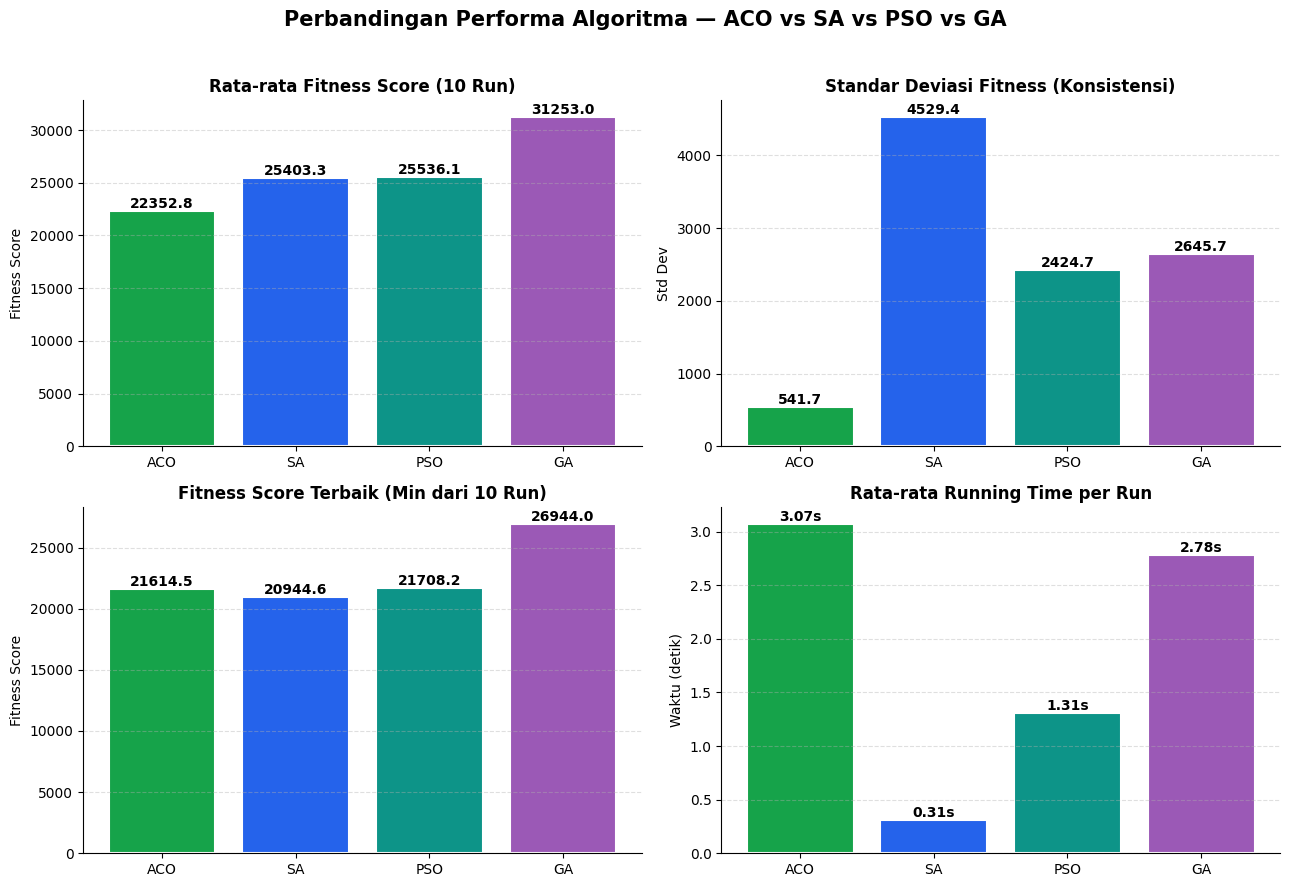

/var/folders/lk/wc9vhhns1fn7k7j4sx2dl0t00000gn/T/ipykernel_67125/3087333583.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_scores, labels=algo_names, patch_artist=True, widths=0.5)


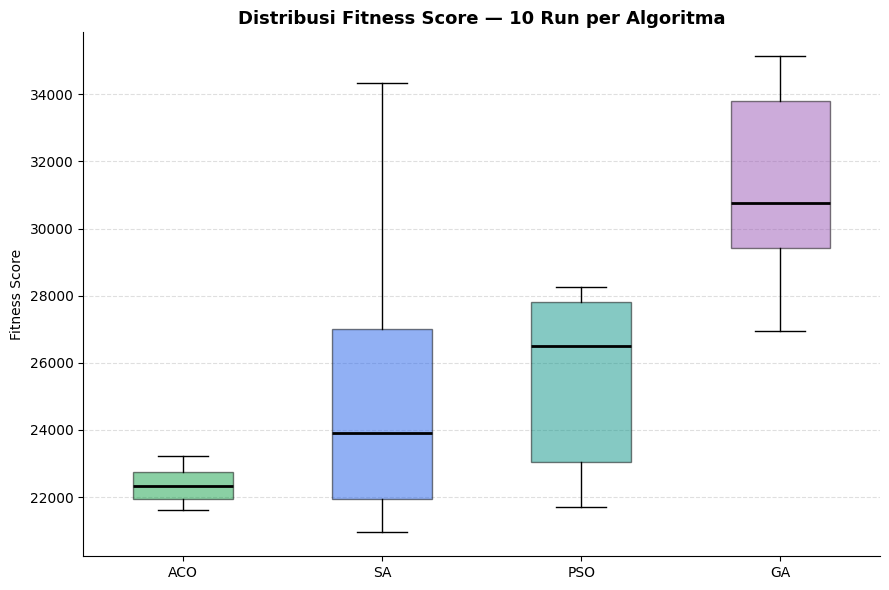

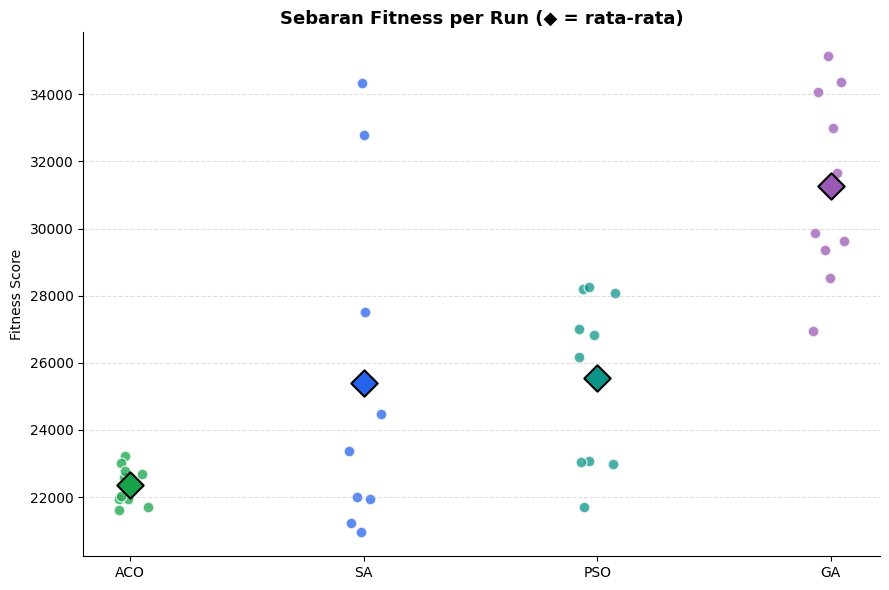

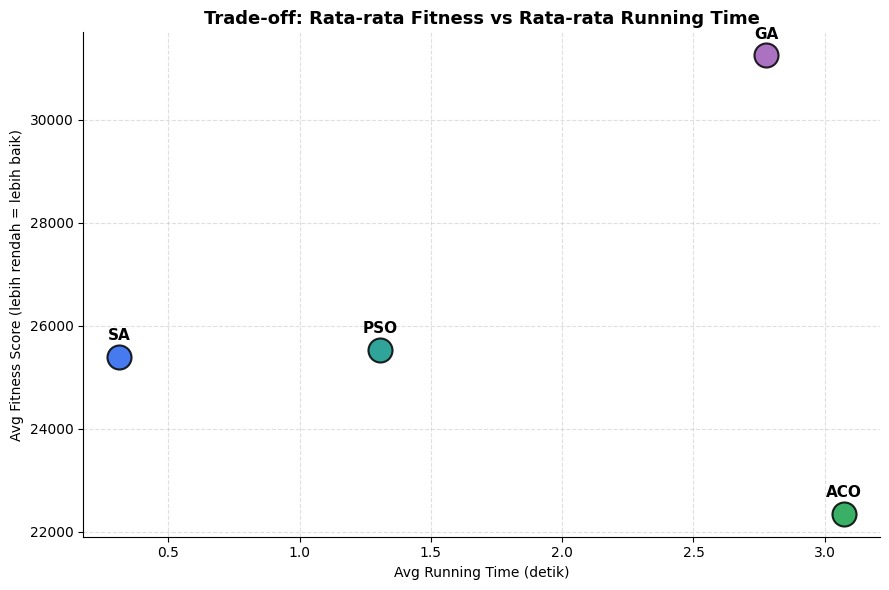


✅ Semua grafik tersimpan: perbandingan_metrik_algoritma.png, boxplot_distribusi_fitness.png, scatter_fitness_per_run.png, tradeoff_fitness_runtime.png

📝 GA sudah diikutkan dalam seluruh grafik perbandingan di atas.


In [78]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 65)
print("📈  VISUALISASI GRAFIK PERBANDINGAN ALGORITMA")
print("=" * 65)

# ── Siapkan data perbandingan ───────────────────────────────────────
algo_names = ["ACO", "SA", "PSO", "GA"]
colors     = {"ACO": "#16a34a", "SA": "#2563eb", "PSO": "#0d9488", "GA": "#9b59b6"}

avg_scores = [stat_aco["avg"], stat_sa["avg"], stat_pso["avg"], stat_ga["avg"]]
std_scores = [stat_aco["std"], stat_sa["std"], stat_pso["std"], stat_ga["std"]]
min_scores = [stat_aco["min"], stat_sa["min"], stat_pso["min"], stat_ga["min"]]
avg_times  = [stat_aco["avg_time"], stat_sa["avg_time"], stat_pso["avg_time"], stat_ga["avg_time"]]
all_scores = [stat_aco["scores"], stat_sa["scores"], stat_pso["scores"], stat_ga["scores"]]

bar_colors = [colors[a] for a in algo_names]


# ════════════════════════════════════════════════════════════════════
# FIGURE 1 — Grid 2x2: Avg Fitness, Std Dev, Min Fitness, Avg Runtime
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Perbandingan Performa Algoritma — ACO vs SA vs PSO vs GA", fontsize=15, fontweight='bold')

# 1. Avg Fitness
ax = axes[0, 0]
bars = ax.bar(algo_names, avg_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Rata-rata Fitness Score (10 Run)", fontweight='bold')
ax.set_ylabel("Fitness Score")
for b, v in zip(bars, avg_scores):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

# 2. Std Dev (konsistensi)
ax = axes[0, 1]
bars = ax.bar(algo_names, std_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Standar Deviasi Fitness (Konsistensi)", fontweight='bold')
ax.set_ylabel("Std Dev")
for b, v in zip(bars, std_scores):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

# 3. Min Fitness (Best)
ax = axes[1, 0]
bars = ax.bar(algo_names, min_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Fitness Score Terbaik (Min dari 10 Run)", fontweight='bold')
ax.set_ylabel("Fitness Score")
for b, v in zip(bars, min_scores):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

# 4. Avg Running Time
ax = axes[1, 1]
bars = ax.bar(algo_names, avg_times, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Rata-rata Running Time per Run", fontweight='bold')
ax.set_ylabel("Waktu (detik)")
for b, v in zip(bars, avg_times):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}s", ha='center', va='bottom', fontweight='bold')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('perbandingan_metrik_algoritma.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 2 — Boxplot distribusi fitness 10 run per algoritma
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(all_scores, labels=algo_names, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(c); patch.set_alpha(0.5)
for median in bp['medians']:
    median.set_color('black'); median.set_linewidth(2)

ax.set_title("Distribusi Fitness Score — 10 Run per Algoritma", fontweight='bold', fontsize=13)
ax.set_ylabel("Fitness Score")
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('boxplot_distribusi_fitness.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 3 — Scatter: Fitness tiap run (sebaran 10 titik per algoritma)
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
for i, (algo, scores) in enumerate(zip(algo_names, all_scores)):
    x = np.full(len(scores), i) + np.random.uniform(-0.08, 0.08, len(scores))
    ax.scatter(x, scores, color=colors[algo], s=60, alpha=0.75, edgecolor='white', linewidth=1, label=algo)
    ax.scatter(i, np.mean(scores), color=colors[algo], s=180, marker='D', edgecolor='black', linewidth=1.5, zorder=5)

ax.set_xticks(range(len(algo_names)))
ax.set_xticklabels(algo_names)
ax.set_title("Sebaran Fitness per Run (◆ = rata-rata)", fontweight='bold', fontsize=13)
ax.set_ylabel("Fitness Score")
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scatter_fitness_per_run.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 4 — Trade-off: Fitness vs Running Time (scatter besar)
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
for algo, avgf, avgt in zip(algo_names, avg_scores, avg_times):
    ax.scatter(avgt, avgf, s=300, color=colors[algo], edgecolor='black', linewidth=1.5, label=algo, alpha=0.85)
    ax.annotate(algo, (avgt, avgf), textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold', fontsize=11)

ax.set_title("Trade-off: Rata-rata Fitness vs Rata-rata Running Time", fontweight='bold', fontsize=13)
ax.set_xlabel("Avg Running Time (detik)")
ax.set_ylabel("Avg Fitness Score (lebih rendah = lebih baik)")
ax.grid(linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tradeoff_fitness_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua grafik tersimpan: perbandingan_metrik_algoritma.png, "
      "boxplot_distribusi_fitness.png, scatter_fitness_per_run.png, tradeoff_fitness_runtime.png")
print("\n📝 GA sudah diikutkan dalam seluruh grafik perbandingan di atas.")

In [86]:
# ─────────────────────────────────────────────────────────────────────
# CELL FINAL: DASHBOARD GABUNGAN PREMIUM COMPACT COMPLETE
# ─────────────────────────────────────────────────────────────────────
import json, os

def build_data_rute_js(rute_terbaik, names, route_registry):
    data_rute_js = []
    for rute in rute_terbaik:
        hari_data = []
        for k in range(len(rute) - 1):
            idx_asal, idx_tujuan = rute[k], rute[k+1]
            key = f"{idx_asal}_{idx_tujuan}"
            if key in route_registry:
                # Cari max elevation dari profil koordinat jalur
                coords = route_registry[key]
                max_elev = max([pt[2] for pt in coords if len(pt) > 2]) if any(len(pt) > 2 for pt in coords) else 0.0
                hari_data.append({
                    "asal_nama": names[idx_asal],
                    "tujuan_nama": names[idx_tujuan],
                    "is_depot_asal": (idx_asal == 0),
                    "is_depot_tujuan": (idx_tujuan == 0),
                    "max_elevation": max_elev,
                    "jalur": coords
                })
        data_rute_js.append(hari_data)
    return data_rute_js

def build_data_metrik(log_metrik, rute_terbaik, names, route_registry):
    hasil = []
    for log, rute in zip(log_metrik, rute_terbaik):
        num_edges = len(rute) - 1
        skor_total = log["Skor Jalan OSMnx"]
        avg_skor = skor_total / num_edges if num_edges > 0 else 0.0
        
        # Cari Max Elevation kumulatif/tertinggi untuk hari ini dari route_registry
        max_elev_hari = 0.0
        for k in range(len(rute) - 1):
            key = f"{rute[k]}_{rute[k+1]}"
            if key in route_registry:
                coords = route_registry[key]
                elevs = [pt[2] for pt in coords if len(pt) > 2]
                if elevs:
                    max_elev_hari = max(max_elev_hari, max(elevs))
                    
        # Mengambil Fitness Score dari hasil log eksperimen Anda
        fit_score = log.get("Fitness Score", log.get("Fitness", 0.0))
        
        hasil.append({
            "hari": log["Hari/Trip"],
            "jarak": log["Jarak (Km)"],
            "fatigue": log["Fatigue Index"],
            "jalan": avg_skor,
            "fitness": fit_score,
            "max_elevation_hari": max_elev_hari
        })
    return hasil

# --- Susun data rute & metrik untuk masing-masing algoritma ---
rute_js_sa  = build_data_rute_js(rute_sa,  names, route_registry)
rute_js_aco = build_data_rute_js(rute_aco, names, route_registry)
rute_js_pso = build_data_rute_js(rute_pso, names, route_registry)
rute_js_ga  = build_data_rute_js(rute_ga,  names, route_registry)

metrik_sa  = build_data_metrik(log_sa, rute_sa, names, route_registry)
metrik_aco = build_data_metrik(log_aco, rute_aco, names, route_registry)
metrik_pso = build_data_metrik(log_pso, rute_pso, names, route_registry)
metrik_ga  = build_data_metrik(log_ga, rute_ga, names, route_registry)

DATA_JS = {
    "sa":  {"rute": rute_js_sa,  "metrik": metrik_sa},
    "aco": {"rute": rute_js_aco, "metrik": metrik_aco},
    "pso": {"rute": rute_js_pso, "metrik": metrik_pso},
    "ga":  {"rute": rute_js_ga,  "metrik": metrik_ga},
}

def build_tuning_info(study, best_params, score_final):
    return {
        "best_value_optuna": round(float(study.best_value), 4),
        "best_params": {k: (round(v, 6) if isinstance(v, float) else v) for k, v in best_params.items()},
        "score_final": round(float(score_final), 4),
        "n_trials": len(study.trials),
    }

TUNING_JS = {
    "sa":  build_tuning_info(study_sa,  best_p_sa,  score_sa),
    "aco": build_tuning_info(study_aco, best_p_aco, score_aco),
    "pso": build_tuning_info(study_pso, best_p_pso, score_pso),
    "ga":  build_tuning_info(study_ga,  best_p_ga,  score_ga),
}

DATA_JSON_STR = json.dumps(DATA_JS)
TUNING_JSON_STR = json.dumps(TUNING_JS)
NAMES_TOTAL_VAL = len(names)

html_content = f"""<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Dashboard Optimasi Rute Sepeda — Surabaya</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=Space+Grotesk:wght@500;700&display=swap" rel="stylesheet">
<style>
* ,::before,*::after{{box-sizing:border-box;margin:0;padding:0}}
:root{{
  --sa:#2563eb;--sa-light:#f0f6ff;
  --aco:#16a34a;--aco-light:#f0fdf4;
  --pso:#0d9488;--pso-light:#f0fdfa;
  --ga:#9b59b6;--ga-light:#faf5ff;
  --ink:#0f172a;--ink-mid:#475569;--ink-faint:#94a3b8;
  --surface:#ffffff;--bg:#f1f5f9;--border:#e2e8f0;
  --radius:12px;--sidebar:390px;--header:52px;
  --shadow:0 1px 3px rgba(0,0,0,.08),0 4px 12px rgba(0,0,0,.06);
}}

[data-theme="dark"] {{
  --surface:#1e293b;--bg:#0f172a;--border:#334155;
  --ink:#f8fafc;--ink-mid:#cbd5e1;--ink-faint:#64748b;
  --sa-light:rgba(37,99,235,0.15);--aco-light:rgba(22,163,74,0.15);
  --pso-light:rgba(13,148,136,0.15);--ga-light:rgba(155,89,182,0.15);
}}

html,body{{height:100%;font-family:'Inter',sans-serif;background:var(--bg);color:var(--ink);transition:background .2s,color .2s}}
#shell{{display:flex;flex-direction:column;height:100vh}}
#topbar{{height:var(--header);background:#0f172a;display:flex;align-items:center;gap:16px;padding:0 20px;flex-shrink:0;border-bottom:1px solid var(--border)}}
[data-theme="dark"] #topbar {{background:#1e293b}}

.brand{{font-family:'Space Grotesk',sans-serif;font-size:15px;font-weight:700;color:#fff;letter-spacing:-.3px;white-space:nowrap}}
.brand span{{color:var(--sa)}}

#tab-bar{{display:flex;gap:4px;background:#1e293b;border-radius:8px;padding:4px;margin-left:auto}}
[data-theme="dark"] #tab-bar {{background:#0f172a}}

.tab-btn{{padding:6px 16px;border:none;border-radius:6px;font-family:'Space Grotesk',sans-serif;font-size:12px;font-weight:600;cursor:pointer;transition:all .2s;color:var(--ink-faint);background:transparent}}
.tab-btn.sa.active{{background:var(--sa);color:#fff}}
.tab-btn.aco.active{{background:var(--aco);color:#fff}}
.tab-btn.pso.active{{background:var(--pso);color:#fff}}
.tab-btn.ga.active{{background:var(--ga);color:#fff}}
.tab-btn:not(.active):hover{{color:#fff;background:#334155}}

#theme-toggle-btn{{background:transparent;border:1px solid #334155;border-radius:50%;width:32px;height:32px;cursor:pointer;display:flex;align-items:center;justify-content:center;color:#94a3b8;transition:all .2s}}
#theme-toggle-btn:hover{{color:#fff;border-color:#64748b;background:rgba(255,255,255,0.05)}}

#content{{display:flex;flex:1;overflow:hidden}}
#map-wrap{{flex:1;position:relative}}
#map{{height:100%;width:100%}}
#algo-badge{{position:absolute;top:16px;left:16px;z-index:900;padding:6px 14px;border-radius:20px;font-family:'Space Grotesk',sans-serif;font-size:12px;font-weight:700;color:#fff;box-shadow:var(--shadow)}}
#algo-badge.sa{{background:var(--sa)}}
#algo-badge.aco{{background:var(--aco)}}
#algo-badge.pso{{background:var(--pso)}}
#algo-badge.ga{{background:var(--ga)}}

.elev-legend{{position:absolute;bottom:28px;left:20px;z-index:900;background:var(--surface);padding:12px 14px;border-radius:var(--radius);box-shadow:var(--shadow);min-width:230px;border:1px solid var(--border)}}
.elev-legend-title{{font-size:11px;font-weight:600;color:var(--ink-mid);margin-bottom:6px;text-transform:uppercase;letter-spacing:.5px}}
.grad-bar{{height:10px;border-radius:4px;background:linear-gradient(to right,#27ae60,#f1c40f,#e74c3c)}}
.grad-labels{{display:flex;justify-content:space-between;margin-top:4px;font-size:10px;color:var(--ink-faint)}}

.play-controls{{position:absolute;bottom:28px;right:20px;z-index:900;background:var(--surface);padding:10px 14px;border-radius:var(--radius);box-shadow:var(--shadow);display:flex;align-items:center;gap:10px;font-size:12px;color:var(--ink-mid);border:1px solid var(--border)}}
.play-btn-item{{border:none;border-radius:6px;width:32px;height:32px;cursor:pointer;display:flex;align-items:center;justify-content:center;background:var(--bg);color:var(--ink-mid);transition:all .2s}}
.play-btn-item svg{{width:14px;height:14px;fill:currentColor}}
.play-btn-item:hover:not(:disabled){{background:var(--ink);color:var(--surface)}}
.play-btn-item:disabled{{opacity:.3;cursor:not-allowed}}

#sidebar{{width:var(--sidebar);height:100%;flex-shrink:0;background:var(--surface);border-left:1px solid var(--border);display:flex;flex-direction:column;overflow:hidden;transition:background .2s,border .2s}}
#sidebar-header{{padding:16px 18px 12px;flex-shrink:0;border-bottom:1px solid var(--border)}}
#sidebar-title{{font-family:'Space Grotesk',sans-serif;font-size:15px;font-weight:700;color:var(--ink);margin-bottom:10px}}
#btn-all{{width:100%;padding:9px;border:none;border-radius:7px;font-family:'Space Grotesk',sans-serif;font-size:12px;font-weight:700;cursor:pointer;transition:all .2s;color:#fff;margin-bottom:8px}}
#btn-all.sa{{background:var(--sa)}}
#btn-all.aco{{background:var(--aco)}}
#btn-all.pso{{background:var(--pso)}}
#btn-all.ga{{background:var(--ga)}}
#btn-tuning{{width:100%;padding:8px;border:1.5px solid var(--border);border-radius:7px;background:var(--surface);font-family:'Space Grotesk',sans-serif;font-size:11px;font-weight:700;color:var(--ink-mid);cursor:pointer;transition:all .2s}}
#btn-tuning:hover{{background:var(--bg)}}

#stats-strip{{display:grid;grid-template-columns:repeat(3,1fr);gap:6px;padding:10px 14px;background:var(--bg);border-bottom:1px solid var(--border);flex-shrink:0}}
.stat-pill{{background:var(--surface);border:1px solid var(--border);border-radius:8px;padding:8px 4px;text-align:center}}
.stat-pill .sv{{font-size:14px;font-weight:700;color:var(--ink);letter-spacing:-0.3px}}
.stat-pill .sl{{font-size:9.5px;color:var(--ink-faint);margin-top:2px;font-weight:500}}

#cards-wrap{{flex:1;overflow-y:auto;padding:14px;display:flex;flex-direction:column;gap:12px}}
.day-card{{border:1.5px solid var(--border);border-radius:var(--radius);padding:14px;cursor:pointer;transition:all .2s ease;background:var(--surface);position:relative}}
.day-card:hover{{box-shadow:var(--shadow);transform:translateY(-1px)}}
.day-card.active-sa{{border-color:var(--sa);background:linear-gradient(180deg, var(--surface) 0%, var(--sa-light) 100%)}}
.day-card.active-aco{{border-color:var(--aco);background:linear-gradient(180deg, var(--surface) 0%, var(--aco-light) 100%)}}
.day-card.active-pso{{border-color:var(--pso);background:linear-gradient(180deg, var(--surface) 0%, var(--pso-light) 100%)}}
.day-card.active-ga{{border-color:var(--ga);background:linear-gradient(180deg, var(--surface) 0%, var(--ga-light) 100%)}}

.card-top{{display:flex;align-items:center;gap:8px;margin-bottom:10px}}
.day-badge{{padding:3px 9px;border-radius:20px;font-size:10px;font-weight:700;color:#fff}}
.day-badge.sabtu{{background:#dc2626}}
.day-badge.minggu{{background:#16a34a}}
.card-title{{font-size:13px;font-weight:600;color:var(--ink)}}

/* Presisi Layout untuk Grid 4 Kolom di Dalam Kartu */
.metrics{{display:grid;grid-template-columns:repeat(4, 1fr);gap:5px;margin-top:8px}}
.metric-box{{background:var(--bg);border-radius:6px;padding:6px 4px;text-align:center}}
.metric-box .mk{{font-size:9px;color:var(--ink-faint);margin-bottom:2px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}}
.metric-box .mv{{font-size:11px;font-weight:700;color:var(--ink);white-space:nowrap}}

.day-card .card-route-flow {{margin-top: 0px;}}
.day-card[class*="active-"] .card-route-flow {{
  background: var(--surface); border: 1px solid var(--border); border-radius: 8px; padding: 12px 14px; margin-top: 12px;
}}

.metro-track {{position: relative; padding-left: 20px; display: flex; flex-direction: column; gap: 11px;}}
.metro-track::before {{content: ''; position: absolute; left: 5px; top: 5px; bottom: 5px; width: 2px; background: var(--ink-faint); opacity: 0.3;}}
.day-card.active-sa .metro-track::before {{ background: var(--sa); opacity:0.4; }}
.day-card.active-aco .metro-track::before {{ background: var(--aco); opacity:0.4; }}
.day-card.active-pso .metro-track::before {{ background: var(--pso); opacity:0.4; }}
.day-card.active-ga .metro-track::before {{ background: var(--ga); opacity:0.4; }}

.metro-node {{position: relative; font-size: 11.5px; font-weight: 500; color: var(--ink-mid); line-height: 1.3;}}
.metro-node::before {{content: ''; position: absolute; left: -20px; top: 4px; width: 10px; height: 10px; border-radius: 50%; background: var(--surface); border: 2px solid var(--ink-mid); box-shadow: 0 0 0 2px var(--surface); z-index: 2;}}
.metro-node.is-depot {{font-weight: 700; color: var(--ink);}}
.metro-node.is-depot::before {{background: #e74c3c !important; border-color: #e74c3c !important;}}

.day-card.active-sa .metro-node:not(.is-depot)::before {{ border-color: var(--sa); background: var(--sa-light); }}
.day-card.active-aco .metro-node:not(.is-depot)::before {{ border-color: var(--aco); background: var(--aco-light); }}
.day-card.active-pso .metro-node:not(.is-depot)::before {{ border-color: var(--pso); background: var(--pso-light); }}
.day-card.active-ga .metro-node:not(.is-depot)::before {{ border-color: var(--ga); background: var(--ga-light); }}

.sv-popup-container {{ font-family: 'Inter', sans-serif; width: 250px; color: #0f172a !important; }}
.sv-iframe-wrapper {{ width: 100%; height: 140px; margin-top: 8px; border-radius: 8px; overflow: hidden; border: 1px solid #cbd5e1; background: #cbd5e1; }}
.sv-iframe-wrapper iframe {{ width: 100%; height: 100%; border: none; }}

#banned-notice{{margin:0 14px 10px;padding:8px 12px;background:#fef3c7;border:1px solid #fcd34d;border-radius:8px;font-size:11px;color:#92400e;display:none}}
#ga-empty{{flex:1;display:flex;align-items:center;justify-content:center;flex-direction:column;gap:8px;color:var(--ink-faint);text-align:center;padding:30px}}

#tuning-overlay{{position:fixed;inset:0;background:rgba(15,23,42,.45);z-index:2000;display:none;align-items:center;justify-content:center}}
#tuning-overlay.show{{display:flex}}
#tuning-panel{{background:var(--surface);border-radius:14px;max-width:520px;width:90%;max-height:80vh;overflow-y:auto;padding:22px 24px;box-shadow:0 12px 40px rgba(0,0,0,.25);border:1px solid var(--border)}}
#tuning-panel h3{{font-family:'Space Grotesk',sans-serif;font-size:17px;margin-bottom:14px;display:flex;align-items:center;justify-content:space-between}}
#tuning-panel .close-btn{{border:none;background:var(--bg);border-radius:50%;width:28px;height:28px;cursor:pointer;font-size:14px;color:var(--ink-mid)}}
.tuning-block{{border:1px solid var(--border);border-radius:10px;padding:12px 14px;margin-bottom:10px}}
.tuning-block .tb-title{{font-family:'Space Grotesk',sans-serif;font-weight:700;font-size:12.5px;margin-bottom:8px;display:flex;align-items:center;gap:8px}}
.tuning-block .tb-dot{{width:10px;height:10px;border-radius:50%}}
.tuning-row{{display:flex;justify-content:space-between;font-size:12px;padding:3px 0;color:var(--ink-mid)}}
.tuning-row b{{color:var(--ink)}}
.tuning-params{{margin-top:6px;background:var(--bg);border-radius:8px;padding:8px 10px;font-size:11.5px}}
.tuning-params .pr{{display:flex;justify-content:space-between;padding:2px 0}}
</style>
</head>
<body data-theme="light">
<div id="shell">
  <div id="topbar">
    <div class="brand">🚴 Surabaya<span>Route</span> · Optimasi Rute Sepeda</div>
    <div id="tab-bar">
      <button class="tab-btn sa active" onclick="switchTab('sa')">Simulated Annealing <span class="tab-badge">SA</span></button>
      <button class="tab-btn aco" onclick="switchTab('aco')">Ant Colony Opt. <span class="tab-badge">ACO</span></button>
      <button class="tab-btn pso" onclick="switchTab('pso')">Particle Swarm Opt. <span class="tab-badge">PSO</span></button>
      <button class="tab-btn ga" onclick="switchTab('ga')">Genetic Algorithm <span class="tab-badge">GA</span></button>
    </div>
    <button id="theme-toggle-btn" onclick="toggleTheme()" title="Ubah Tema Warna">
      <svg xmlns="http://www.w3.org/2000/svg" width="18" height="18" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round">
        <path d="M21 12.79A9 9 0 1 1 11.21 3 7 7 0 0 0 21 12.79z"></path>
      </svg>
    </button>
  </div>
  <div id="content">
    <div id="map-wrap">
      <div id="map"></div>
      <div id="algo-badge" class="sa">Simulated Annealing</div>
      <div class="elev-legend">
        <div class="elev-legend-title">Arah Tanjakan Laju Sepeda</div>
        <div class="grad-bar"></div>
        <div class="grad-labels"><span>0m (Datar/Turunan)</span><span>Landai</span><span>>4m (Curam)</span></div>
      </div>
      <div class="play-controls">
        <button id="btn-play" class="play-btn-item" title="Mulai animasi rute" disabled>
          <svg viewBox="0 0 24 24"><path d="M8 5v14l11-7z"/></svg>
        </button>
        <button id="btn-stop" class="play-btn-item" title="Hentikan animasi">
          <svg viewBox="0 0 24 24"><path d="M6 6h12v12H6z"/></svg>
        </button>
        <span id="play-label">Pilih hari untuk animasi</span>
      </div>
    </div>
    <div id="sidebar">
      <div id="sidebar-header">
        <div id="sidebar-title">Itinerary Multi-Hari — SA</div>
        <button id="btn-all" class="sa" onclick="tampilkanSemua()">Tampilkan Seluruh Rute</button>
        <button id="btn-tuning" onclick="openTuning()">⚙️ Lihat Hasil Tuning Parameter (Optuna)</button>
      </div>
      <div id="stats-strip">
        <div class="stat-pill"><div class="sv" id="stat-hari">—</div><div class="sl">Total Hari</div></div>
        <div class="stat-pill"><div class="sv" id="stat-km">—</div><div class="sl">Total Km</div></div>
        <div class="stat-pill"><div class="sv" id="stat-fatigue">—</div><div class="sl">Avg Fatigue</div></div>
      </div>
      <div id="banned-notice"></div>
      <div id="cards-wrap"></div>
    </div>
  </div>
</div>

<div id="tuning-overlay">
  <div id="tuning-panel">
    <h3>⚙️ Hasil Tuning Parameter (Optuna) <button class="close-btn" onclick="closeTuning()">✕</button></h3>
    <div id="tuning-content"></div>
  </div>
</div>

<script>
const DATA = {DATA_JSON_STR};
const TUNING = {TUNING_JSON_STR};
const NAMES_TOTAL = {NAMES_TOTAL_VAL};
const ALGO_LABEL = {{
  sa: 'Simulated Annealing', aco: 'Ant Colony Optimization',
  pso: 'Particle Swarm Optimization', ga: 'Genetic Algorithm'
}};
const COLOR_MAP = {{ sa:'#2563eb', aco:'#16a34a', pso:'#0d9488', ga:'#9b59b6' }};

const map = L.map('map').setView([-7.262015, 112.739727], 13);
let lightTiles = L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{attribution:'© CARTO'}});
let darkTiles = L.tileLayer('https://{{s}}.basemaps.cartocdn.com/dark_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{attribution:'© CARTO'}});

lightTiles.addTo(map);

let layerGroup = L.layerGroup().addTo(map);
let activeTab = 'sa';

let animMarker = null;
let animTimer = null;
let animFlatPoints = [];   
let animIdx = 0;
let animDayIdx = null;     

function toggleTheme() {{
  const body = document.body;
  const currentTheme = body.getAttribute('data-theme');
  const btn = document.getElementById('theme-toggle-btn');
  
  if (currentTheme === 'dark') {{
    body.setAttribute('data-theme', 'light');
    map.removeLayer(darkTiles);
    lightTiles.addTo(map);
    btn.innerHTML = `<svg xmlns="http://www.w3.org/2000/svg" width="18" height="18" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M21 12.79A9 9 0 1 1 11.21 3 7 7 0 0 0 21 12.79z"></path></svg>`;
  }} else {{
    body.setAttribute('data-theme', 'dark');
    map.removeLayer(lightTiles);
    darkTiles.addTo(map);
    btn.innerHTML = `<svg xmlns="http://www.w3.org/2000/svg" width="18" height="18" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><circle cx="12" cy="12" r="5"></circle><line x1="12" y1="1" x2="12" y2="3"></line><line x1="12" y1="21" x2="12" y2="23"></line><line x1="4.22" y1="4.22" x2="5.64" y2="5.64"></line><line x1="18.36" y1="18.36" x2="19.78" y2="19.78"></line><line x1="1" y1="12" x2="3" y2="12"></line><line x1="21" y1="12" x2="23" y2="12"></line><line x1="4.22" y1="19.78" x2="5.64" y2="18.36"></line><line x1="18.36" y1="5.64" x2="19.78" y2="4.22"></line></svg>`;
  }}
}}

function slopeColor(diff) {{
    if (diff <= 0) return '#27ae60'; 
    const midDiff = 1.5;  
    const maxDiff = 4.0;  
    let val = Math.min(diff, maxDiff);
    let r, g, b;
    if (val <= midDiff) {{
        let t = val / midDiff;
        r = Math.round(39 + t * (241 - 39));
        g = Math.round(174 + t * (196 - 174));
        b = Math.round(96 + t * (15 - 96));
    }} else {{
        let t = (val - midDiff) / (maxDiff - midDiff);
        r = Math.round(241 + t * (231 - 241));
        g = Math.round(196 + t * (76 - 196));
        b = Math.round(15 + t * (60 - 15));
    }}
    return `rgb(${{r}}, ${{g}}, ${{b}})`;
}}

function stopAnimation() {{
  if (animTimer) {{ clearInterval(animTimer); animTimer = null; }}
  if (animMarker) {{ map.removeLayer(animMarker); animMarker = null; }}
  document.getElementById('play-label').textContent = animDayIdx===null ? 'Pilih hari untuk animasi' : 'Animasi dihentikan';
  document.getElementById('btn-play').disabled = (animDayIdx===null);
}}

function bikeIcon() {{
  return L.divIcon({{
    html: `<div style="font-size:22px;line-height:22px;transform:translate(-50%,-50%);filter:drop-shadow(0 2px 3px rgba(0,0,0,.45))">🚴</div>`,
    className: '', iconSize: [0,0]
  }});
}}

function renderMap(idxList) {{
  layerGroup.clearLayers();
  stopAnimation();
  const rute=DATA[activeTab].rute, col=COLOR_MAP[activeTab];
  const seen=new Set(), bounds=[];
  animFlatPoints = [];
  animDayIdx = (idxList.length === 1) ? idxList[0] : null;

  idxList.forEach(idx => {{
    (rute[idx]||[]).forEach(seg => {{
      const poly=seg.jalur;
      const maxElevSeg = seg.max_elevation || 0.0;
      
      for (let i=0;i<poly.length-1;i++) {{
        const p1=poly[i],p2=poly[i+1];
        const diff = p2[2] - p1[2]; 
        L.polyline([[p1[0], p1[1]], [p2[0], p2[1]]], {{color:slopeColor(diff),weight:5,opacity:.85}}).addTo(layerGroup);
        bounds.push([p1[0],p1[1]]);
        if(idxList.length === 1) animFlatPoints.push([p1[0],p1[1]]);
      }}
      if(idxList.length === 1) animFlatPoints.push([poly[poly.length-1][0], poly[poly.length-1][1]]);

      [[poly[0],seg.asal_nama,seg.is_depot_asal],[poly[poly.length-1],seg.tujuan_nama,seg.is_depot_tujuan]].forEach(([pt,nm,isDep])=>{{
        if(seen.has(nm)) return; seen.add(nm);
        
        const embedUrl = `https://maps.google.com/maps?q=${{pt[0]}},${{pt[1]}}&cbll=${{pt[0]}},${{pt[1]}}&layer=c&txt=&cbp=12,20,0,0,0&output=svembed`;
        
        const popupContent = `
          <div class="sv-popup-container">
            <b style="font-size:13px; color:#0f172a; display:block; margin-bottom:2px;">${{nm}}</b>
            <div style="font-size:11px;color:#475569;margin-bottom:2px;display:flex;justify-content:between;gap:10px;">
              <span>Elevasi: ${{pt[2]!=null?pt[2].toFixed(1):'0'}}m</span>
              <span style="font-weight:600;color:#e74c3c">Max Elev Jalur: ${{maxElevSeg.toFixed(1)}}m</span>
            </div>
            <div class="sv-iframe-wrapper">
              <iframe src="${{embedUrl}}" allowfullscreen="" loading="lazy"></iframe>
            </div>
          </div>
        `;

        L.circleMarker([pt[0],pt[1]],{{radius:isDep?9:6,color:'white',weight:2,fillColor:isDep?'#e74c3c':col,fillOpacity:1}})
        .bindPopup(popupContent, {{maxWidth: 280}}).addTo(layerGroup);
      }});
    }});
  }});
  if(bounds.length) map.fitBounds(bounds,{{padding:[30,30]}});

  const playLabel = document.getElementById('play-label');
  const btnPlay = document.getElementById('btn-play');
  if (animDayIdx !== null && animFlatPoints.length > 1) {{
    playLabel.textContent = 'Siap memutar rute hari ini';
    btnPlay.disabled = false;
  }} else {{
    playLabel.textContent = 'Pilih hari untuk animasi';
    btnPlay.disabled = true;
  }}
}}

function playAnimation() {{
  if (animFlatPoints.length < 2) return;
  if (animTimer) clearInterval(animTimer);
  if (animMarker) map.removeLayer(animMarker);

  animIdx = 0;
  animMarker = L.marker(animFlatPoints[0], {{icon: bikeIcon()}}).addTo(layerGroup);
  document.getElementById('play-label').textContent = 'Memutar... 0%';

  const totalSteps = animFlatPoints.length;
  const intervalMs = Math.max(15, Math.min(120, Math.round(8000 / totalSteps)));

  animTimer = setInterval(() => {{
    animIdx++;
    if (animIdx >= totalSteps) {{
      animMarker.setLatLng(animFlatPoints[totalSteps-1]);
      document.getElementById('play-label').textContent = 'Selesai ✓';
      clearInterval(animTimer); animTimer = null;
      return;
    }}
    animMarker.setLatLng(animFlatPoints[animIdx]);
    const pct = Math.round((animIdx/(totalSteps-1))*100);
    document.getElementById('play-label').textContent = `Memutar... ${{pct}}%`;
  }}, intervalMs);
}}

document.getElementById('btn-play').addEventListener('click', playAnimation);
document.getElementById('btn-stop').addEventListener('click', stopAnimation);

function cekBannedNodes(tab) {{
  const seen=new Set();
  DATA[tab].rute.forEach(hari=>hari.forEach(seg=>{{seen.add(seg.asal_nama);seen.add(seg.tujuan_nama);}}));
  const notice=document.getElementById('banned-notice');
  const selisih=NAMES_TOTAL-seen.size;
  if(selisih>0){{notice.style.display='block';notice.textContent=`⚠️ ${{selisih}} destinasi di-banned (jarak melebihi batas).`;}}
  else notice.style.display='none';
}}

function buildMetroTimelineHtml(idx) {{
  const segs = DATA[activeTab].rute[idx] || [];
  if (!segs.length) return '';
  const nodes = [{{ name: segs[0].asal_nama, isDepot: segs[0].is_depot_asal }}];
  segs.forEach(s => {{ nodes.push({{ name: s.tujuan_nama, isDepot: s.is_depot_tujuan }}); }});
  
  let html = '<div class="metro-track">';
  nodes.forEach(node => {{
    const depotClass = node.isDepot ? 'is-depot' : '';
    html += `<div class="metro-node ${{depotClass}}">${{node.name}}</div>`;
  }});
  html += '</div>';
  return html;
}}

function buildCards() {{
  const metrik=DATA[activeTab].metrik, wrap=document.getElementById('cards-wrap');
  wrap.innerHTML='';

  if (activeTab === 'ga' && metrik.length === 0) {{
    ['stat-hari','stat-km','stat-fatigue'].forEach(id=>document.getElementById(id).textContent='—');
    document.getElementById('banned-notice').style.display='none';
    wrap.innerHTML = `<div id="ga-empty"><div>🧬</div><div style="font-weight:700;margin-top:8px;">Genetic Algorithm</div><div style="font-size:12px;color:var(--ink-faint)">Implementasi menyusul.</div></div>`;
    return;
  }}

  const totalKm=metrik.reduce((s,m)=>s+m.jarak,0);
  const avgFat=metrik.reduce((s,m)=>s+m.fatigue,0)/metrik.length;

  document.getElementById('stat-hari').textContent=metrik.length;
  document.getElementById('stat-km').textContent=totalKm.toFixed(1);
  document.getElementById('stat-fatigue').textContent=avgFat.toFixed(1);
  
  metrik.forEach((m,idx)=>{{
    const isSabtu=m.hari.toLowerCase().includes('sabtu');
    const metroTimeline = buildMetroTimelineHtml(idx);
    const maxElevVal = m.max_elevation_hari != null ? m.max_elevation_hari.toFixed(1) : '0.0';

    const card=document.createElement('div'); card.className='day-card';
    card.innerHTML=`
      <div class="card-top">
        <span class="day-badge ${{isSabtu?'sabtu':'minggu'}}">${{isSabtu?'SABTU':'MINGGU'}}</span>
        <span class="card-title">${{m.hari}}</span>
      </div>
      <div class="metrics">
        <div class="metric-box"><div class="mk">Jarak</div><div class="mv">${{m.jarak.toFixed(1)}}k</div></div>
        <div class="metric-box"><div class="mk">Fatigue</div><div class="mv">${{m.fatigue.toFixed(0)}}</div></div>
        <div class="metric-box"><div class="mk">Skor Jalan</div><div class="mv">${{m.jalan.toFixed(2)}}</div></div>
        <div class="metric-box"><div class="mk">Max Elev</div><div class="mv">${{maxElevVal}}m</div></div>
      </div>
      <div class="card-route-flow" style="display:none; margin-top:12px;">
        <div class="detil-metro">${{metroTimeline}}</div>
      </div>`;
      
    card.onclick=()=>{{
      document.querySelectorAll('.day-card').forEach(c=>{{
        c.classList.remove('active-sa','active-aco','active-pso','active-ga');
        const cFlow = c.querySelector('.card-route-flow');
        if(cFlow) cFlow.style.display = 'none';
      }});
      card.classList.add(`active-${{activeTab}}`);
      card.querySelector('.card-route-flow').style.display = 'block';
      renderMap([idx]);
    }};
    wrap.appendChild(card);
  }});
  cekBannedNodes(activeTab);
}}

function tampilkanSemua() {{
  document.querySelectorAll('.day-card').forEach(c=>{{
    c.classList.remove('active-sa','active-aco','active-pso','active-ga');
    const cFlow = c.querySelector('.card-route-flow');
    if(cFlow) cFlow.style.display = 'none';
  }});
  if (activeTab === 'ga' && DATA.ga.metrik.length === 0) {{ layerGroup.clearLayers(); stopAnimation(); animDayIdx=null; return; }}
  renderMap(DATA[activeTab].metrik.map((_,i)=>i));
}}

function switchTab(tab) {{
  activeTab=tab;
  document.querySelectorAll('.tab-btn').forEach(b=>b.classList.remove('active'));
  document.querySelector(`.tab-btn.${{tab}}`).classList.add('active');
  const badge=document.getElementById('algo-badge');
  badge.className=tab; badge.textContent=ALGO_LABEL[tab];
  const btnAll=document.getElementById('btn-all');
  btnAll.className=tab;
  document.getElementById('sidebar-title').textContent='Itinerary Multi-Hari — '+tab.toUpperCase();
  buildCards(); tampilkanSemua();
}}

function openTuning() {{
  const wrap = document.getElementById('tuning-content');
  wrap.innerHTML = '';
  ['sa','aco','pso','ga'].forEach(algo => {{
    const t = TUNING[algo]; if (!t) return;
    const block = document.createElement('div'); block.className = 'tuning-block';
    let paramsHtml = '';
    Object.entries(t.best_params).forEach(([k,v]) => {{ paramsHtml += `<div class="pr"><span>${{k}}</span><b>${{v}}</b></div>`; }});
    block.innerHTML = `
      <div class="tb-title"><span class="tb-dot" style="background:${{COLOR_MAP[algo]}}"></span>${{ALGO_LABEL[algo]}} (${{algo.toUpperCase()}})</div>
      <div class="tuning-row"><span>Skor Optuna Terbaik</span><b>${{t.best_value_optuna}}</b></div>
      <div class="tuning-row"><span>Skor Run Final</span><b>${{t.score_final}}</b></div>
      <div class="tuning-row"><span>Jumlah Trial</span><b>${{t.n_trials}}</b></div>
      <div class="tuning-params"><div style="font-weight:700;margin-bottom:4px;color:var(--ink-mid)">Parameter:</div>${{paramsHtml}}</div>`;
    wrap.appendChild(block);
  }});
  document.getElementById('tuning-overlay').classList.add('show');
}}
function closeTuning() {{ document.getElementById('tuning-overlay').classList.remove('show'); }}
document.getElementById('tuning-overlay').addEventListener('click', (e) => {{ if (e.target.id === 'tuning-overlay') closeTuning(); }});

buildCards(); tampilkanSemua();
</script>
</body>
</html>"""

TARGET_FOLDER = os.path.join('osmnx_inputs')
if not os.path.exists(TARGET_FOLDER):
    os.makedirs(TARGET_FOLDER)

OUTPUT_DASHBOARD = os.path.join(TARGET_FOLDER, 'dashboard_interaktif_multi_algo.html')
with open(OUTPUT_DASHBOARD, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"🎉 Sukses! Dashboard Premium Berhasil Diekspor Ke: {OUTPUT_DASHBOARD}")

🎉 Sukses! Dashboard Premium Berhasil Diekspor Ke: osmnx_inputs/dashboard_interaktif_multi_algo.html
